<center><h1>Wang_Selena_HW2</h1></center>
<br>
<br>

Name: Selena Wang
<br>
Github Username: slnwang
<br>
USC ID: 6791950498

## 1. Combined Cycle Power Plant Data Set

### (a) Download Data

Package imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf

from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler

Get the Cycle Power Plant Data Set

In [2]:
df = pd.read_excel('../data/Folds5x2_pp.xlsx')
df

,AT,V,AP,RH,PE
0,14.96,41.76,1024.07,73.17,463.26
1,25.18,62.96,1020.04,59.08,444.37
2,5.11,39.40,1012.16,92.14,488.56
3,20.86,57.32,1010.24,76.64,446.48
4,10.82,37.50,1009.23,96.62,473.90
...,...,...,...,...,...
9563,16.65,49.69,1014.01,91.00,460.03
9564,13.19,39.18,1023.67,66.78,469.62
9565,31.32,74.33,1012.92,36.48,429.57
9566,24.48,69.45,1013.86,62.39,435.74


### (b) Exploring the data

#### i. rows and columns

In [3]:
print(f"rows: {df.shape[0]}, columns: {df.shape[1]}")
print(df.columns)

rows: 9568, columns: 5
Index(['AT', 'V', 'AP', 'RH', 'PE'], dtype='object')


There are 9568 rows and 5 columns in the dataset. One row represents the average ambient variables Temperature, Ambient Pressure, Relative Humidity and Exhaust Vacuum over that hour and the net electrical energy output produced in that hour.  

*Note:* Dataset and HW handout are inconsistent with electricall energy output column name ('EP' vs 'PE'). Practically there is no need to rename so I will be referrring to it as 'PE' as seen in the data to avoid confusion. I will also keep Temperature as AT vs T.


#### ii. pairwise scatterplots of all the varianbles

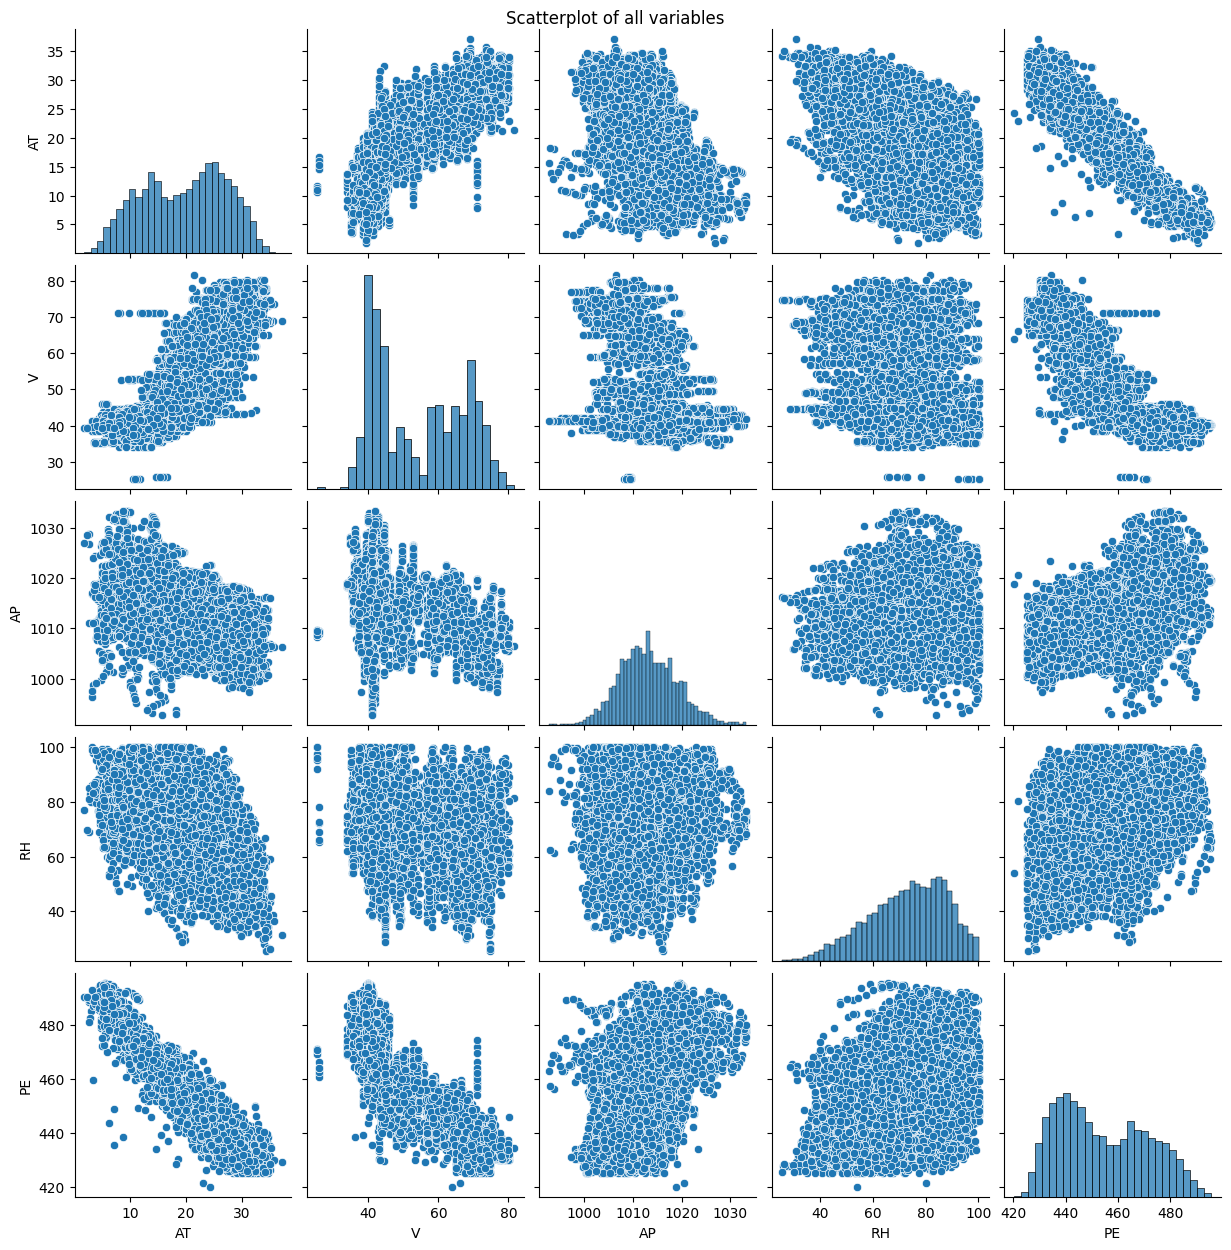

In [4]:
sns.pairplot(df)
plt.suptitle('Scatterplot of all variables', y = 1)
plt.show()

Looking at the pairwise scatterplots, here are my findings:
* Energy Output (PE) and Average Temperature (AT) appear to have a strong linear negative correlation.
* Exhaust Vacuum (V) and Energy Output (PE)appear to have a negative correlation but more curved, not as linear as PE vs AT
* Exhaust Vacuum (V) and Average Temperature (AT) appear to have a positive correlation, also curved instead of linear. There is multicollinearity present (since this is correlation between predictors). This  could lead to inflated standard errors, harder to interpret coefficents and more unstable estimates.
* Other pairs of variables do not appear to have any correlations with each other
* Average Temperature (AT) is slightly left skewed and bimodal. This is likely due to the temperatures changing throughout the seasons/year. One peak is for average of the hotter temperatures and one for cooler.
* Exhaust Vacuum (V) is bimodal and right skewed. This could also be affected by the seasons, tied to the machines working harder in summer and winter due to the more extreme temperatures.
* Ambient Pressure (AP) is unimodal and approximately normally distributed
* Relative Humidity (RH) is left skewed and unimodal
* Energy Output (PE) is bimodal and right skewed.


#### iii. mean, the median, range, first and third quartiles, and interquartile ranges

In [5]:
desc = df.describe()

range_row = df.max()-df.min()
range_row.name = "range"

iqr_row = df.quantile(0.75) - df.quantile(0.25)
iqr_row.name = "IQR"

desc = pd.concat([desc, range_row.to_frame().T])
desc = pd.concat([desc, iqr_row.to_frame().T])

print(desc)

                AT            V           AP           RH           PE
count  9568.000000  9568.000000  9568.000000  9568.000000  9568.000000
mean     19.651231    54.305804  1013.259078    73.308978   454.365009
std       7.452473    12.707893     5.938784    14.600269    17.066995
min       1.810000    25.360000   992.890000    25.560000   420.260000
25%      13.510000    41.740000  1009.100000    63.327500   439.750000
50%      20.345000    52.080000  1012.940000    74.975000   451.550000
75%      25.720000    66.540000  1017.260000    84.830000   468.430000
max      37.110000    81.560000  1033.300000   100.160000   495.760000
range    35.300000    56.200000    40.410000    74.600000    75.500000
IQR      12.210000    24.800000     8.160000    21.502500    28.680000


### (c) Simple Linear Regression

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.899
Model:                            OLS   Adj. R-squared:                  0.899
Method:                 Least Squares   F-statistic:                 8.510e+04
Date:                Fri, 25 Sep 2026   Prob (F-statistic):               0.00
Time:                        22:07:16   Log-Likelihood:                -29756.
No. Observations:                9568   AIC:                         5.952e+04
Df Residuals:                    9566   BIC:                         5.953e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    497.0341      0.156   3177.280      0.0

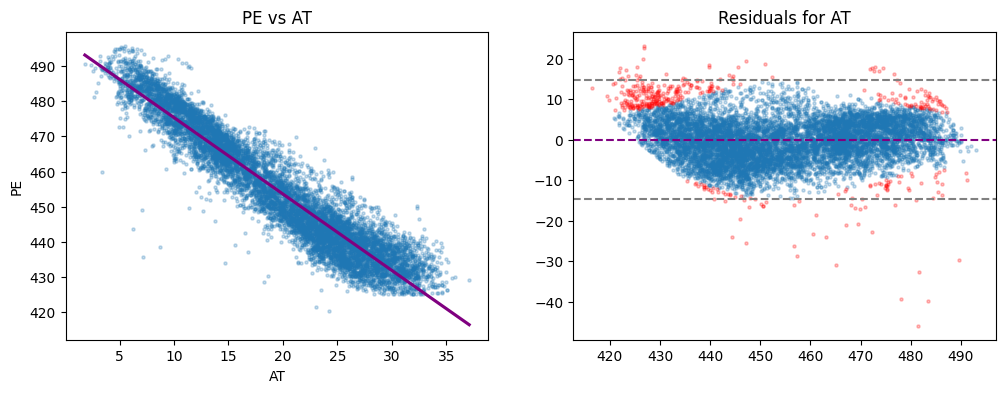

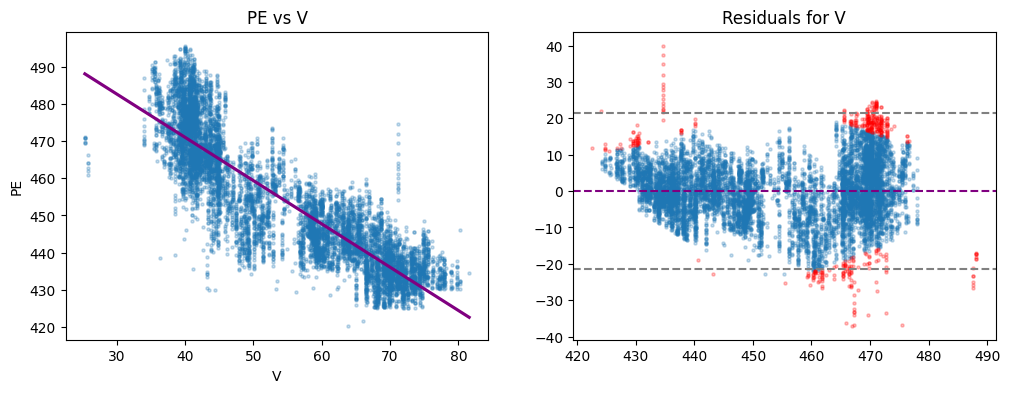

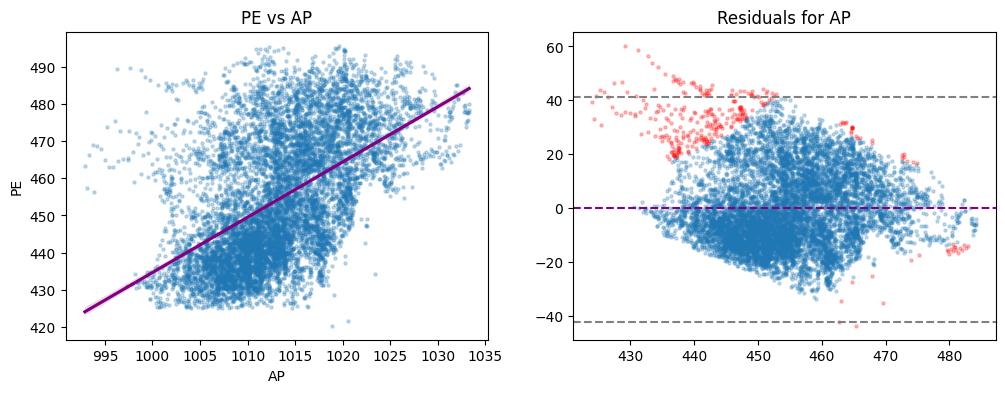

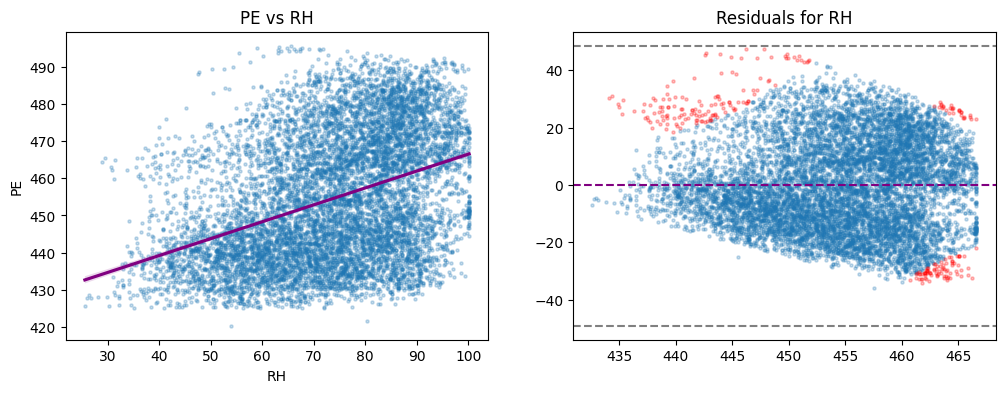

In [6]:
model_summary = []

for p in df.columns[0:-1]:
  model = smf.ols(f'PE ~ {p}', data = df).fit()
  model_summary.append({
        'predictor': p,
        'coef': model.params[p],
        'p_value': model.pvalues[p],
        'significant': model.pvalues[p] < 0.05
    })

  residuals = model.resid

  # find outliers using Cook's distance
  influence = model.get_influence()
  cooks = influence.cooks_distance[0]
  threshold = 4 / len(df)
  outliers = cooks > threshold

  # IQR rule for outliers
  Q1, Q3 = residuals.quantile(0.25), residuals.quantile(0.75)
  IQR = Q3 - Q1
  lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR

  fig, axes = plt.subplots(1, 2, figsize=(12, 4))

  sns.regplot(x = p, y = 'PE', data = df, ax = axes[0], scatter_kws = {
      'alpha': 0.25, 's': 5}, line_kws={'color': 'purple'})
  axes[0].set_title(f'PE vs {p}')

  axes[1].scatter(model.fittedvalues[~outliers], residuals[~outliers], alpha = 0.25, s = 5)
  axes[1].scatter(model.fittedvalues[outliers], residuals[outliers], alpha = 0.25, s = 5, color = 'red')
  axes[1].axhline(0, color='purple', linestyle='--')
  axes[1].axhline(upper, color='grey', linestyle='--')
  axes[1].axhline(lower, color='grey', linestyle='--')
  axes[1].set_title(f'Residuals for {p}')

  print(model.summary())

model_summary_df = pd.DataFrame(model_summary)
print(model_summary_df)

plt.show()

Looking at the residuals, we can see that all the predictors have outliers using Cook's distance. However, when we use the IQR rule (above Q3 + 1.5 × IQR or below Q1 - 1.5 × IQR), relative humidity (RH) does not appear to have outliers.

The Cook's distance only outliers are points with high leverage, meaning each point is pulling the fitted lines toward itself. On the other hand, the IQR rule only outliers are points with a large residual, meaning the model predicted poorly for those points but those points do not affect the fit of the model meaningfully. Points that are flagged by both IQR __and__ Cook's are points that are both influential and poorly explained by the model, making them the strongest points to remove.

However, in each of the residual models, there appears to be banding present in the Cook's distance outliers. Some of the models also have isolated outliers highlighted by Cook's. The isolated points highlighted by Cook's are better removed as outliers compared to the points that belong to a band/cluster. The banding suggests that the linear models alone are not capturing the relationship between each of the predictors and energy output.

Because Cook's distance directly measures how much a point influences the fitted model, it's the more appropriate criterion to act on if points are to be removed at all. The IQR only outliers tells us the prediction was poor but not if that point influeces the regression. Removing only the IQR-flagged points could leave high-leverage points that are quietly distorting the fit. But, removing IQR points that aren't influential trims noise that aren't harming the model. However, with the banding mentioned previously, removing __all__ the Cook's outliers may remove points that aren't true outliers.

I chose not to remove them for the rest of the models since many of the points that were flagged with Cook's distance showed banding which suggests a missing non-linear relationship that wasn't captured and others may have reflected noise. Since the data is on the larger end as well, (9500+ rows) a small number of flagged points is unlikely to meaningfully change my coefficients or $R^2$

### (d) Multiple Regression

In [7]:
multi_model = smf.ols('PE ~ AT + V + AP + RH', data = df).fit()
print(multi_model.summary())

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.929
Model:                            OLS   Adj. R-squared:                  0.929
Method:                 Least Squares   F-statistic:                 3.114e+04
Date:                Fri, 25 Sep 2026   Prob (F-statistic):               0.00
Time:                        22:07:23   Log-Likelihood:                -28088.
No. Observations:                9568   AIC:                         5.619e+04
Df Residuals:                    9563   BIC:                         5.622e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    454.6093      9.749     46.634      0.0

Looking at the summary, we can see that all predictors have a p-value of less than 0.05, meaning that they are all significant. However, given the note printed at the bottom: "condition number is large, 2.13e+05. This might indicate that there are strong multicollinearity or other numerical problems". This follows what was seen in 1.b.ii\) where Exhaust Vacuum (V) and Average Temperature (AT) appear to have a positive correlation. From the summary chart, we can also see that there is an $R^2$ value of 0.929, meaning that 92.9% of the variance of Energy Output (PE) can be explained by this model.

### (e) 1c Compare to 1d

  predictor      coef  multiple_coef
0        AT -2.171320      -1.977513
1         V -1.168135      -0.233916
2        AP  1.489872       0.062083
3        RH  0.455650      -0.158054


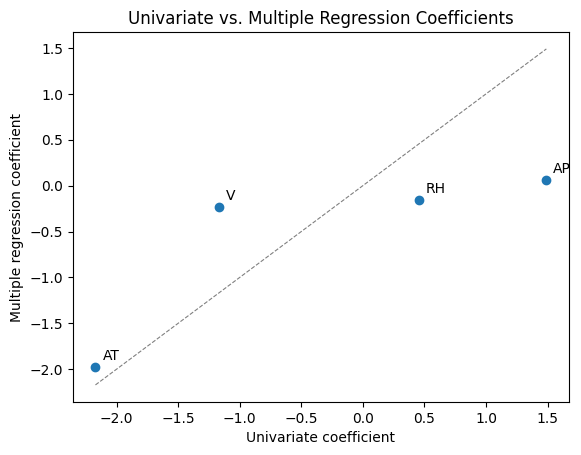

In [8]:
coefs = model_summary_df[['predictor', 'coef']].copy()
coefs['multiple_coef'] = coefs['predictor'].map(multi_model.params)

print(coefs)

lims = [min(coefs['coef'].min(), coefs['multiple_coef'].min()),
        max(coefs['coef'].max(), coefs['multiple_coef'].max())]
plt.plot(lims, lims, color='grey', linestyle='--', linewidth=0.8)

plt.scatter(coefs['coef'], coefs['multiple_coef'])

for _, row in coefs.iterrows():
    plt.annotate(row['predictor'], (row['coef'], row['multiple_coef']),
    xytext=(5, 5), textcoords='offset points')

plt.xlabel('Univariate coefficient')
plt.ylabel('Multiple regression coefficient')
plt.title('Univariate vs. Multiple Regression Coefficients')
plt.show()


Looking at each predictor:
* AT: this predictor lies close to the x=y diagonal (-1.97, -2.17), and barely changes between simple linear and multiple regression.
* V: this predictor sits above the x=y diagonal (-1.17, -0.23), and the coefficient has shrunk towards 0.
* AP: this predictor sits below the x=y diagonal (1.49, 0.06), and the coefficient has also shrunk towards 0.
* RH: this predictor also sits below the x=y diagonal (0.46, -0.16), and the coefficient has not only shrunk toward zero but also flipped sign (positive to negative)

AT's relationship with PE is mostly independent of the other predictors. Its effect on the model is not distorted by the other variables. Having V, AP and RH's coefficients shrink toward 0 in the multiple regression model means their effects are accounted for mostly by AT and each other. They are also most likely correlated with AT and one another as well.

In the simple linear regression RH appears to have a positive effect on PE but in the multiple regression, it flips to negative. So the initial positive relationship doesn't account for RH being correlated with the other predictors. Once we control AT, V and AP, we can see that RH's actual independent effect on PE is slightly negative.

This connects to the previous section where the high condition number already suggested that multicollinearity was present.

### (f) Nonlinear Association

In [9]:
nonlin_summary = []

for p in df.columns[:-1]:
  model = smf.ols(f'PE ~ {p} + I({p}**2) + I({p}**3)', data=df).fit()
  nonlin_summary.append({
      'predictor': p,
      'linear_p': model.pvalues[p],
      'quadratic_p': model.pvalues[f'I({p} ** 2)'],
      'cubic_p': model.pvalues[f'I({p} ** 3)'],
      'nonlinear_evidence': (model.pvalues[f'I({p} ** 2)'] < 0.05) or
       (model.pvalues[f'I({p} ** 3)'] < 0.05)
  })

  print(model.summary())

nonlin_summary_df = pd.DataFrame(nonlin_summary)
print(nonlin_summary_df)

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.912
Model:                            OLS   Adj. R-squared:                  0.912
Method:                 Least Squares   F-statistic:                 3.299e+04
Date:                Fri, 25 Sep 2026   Prob (F-statistic):               0.00
Time:                        22:07:24   Log-Likelihood:                -29101.
No. Observations:                9568   AIC:                         5.821e+04
Df Residuals:                    9564   BIC:                         5.824e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    492.7281      0.673    732.248      0.0

/tmp/ipykernel_16854/2089097820.py:4: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  model = smf.ols(f'PE ~ {p} + I({p}**2) + I({p}**3)', data=df).fit()


                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.154
Model:                            OLS   Adj. R-squared:                  0.153
Method:                 Least Squares   F-statistic:                     579.2
Date:                Fri, 25 Sep 2026   Prob (F-statistic):               0.00
Time:                        22:07:24   Log-Likelihood:                -39923.
No. Observations:                9568   AIC:                         7.985e+04
Df Residuals:                    9564   BIC:                         7.988e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    468.4135     10.545     44.422      0.0

In [10]:
nonlin_summary = []

for p in df.columns[:-1]:
  centered = df[p] - df[p].mean()
  model = smf.ols(f'PE ~ centered + I(centered**2) + I(centered**3)', data=df).fit()
  nonlin_summary.append({
      'predictor': p,
      'linear_p': model.pvalues['centered'],
      'quadratic_p': model.pvalues[f'I(centered ** 2)'],
      'cubic_p': model.pvalues[f'I(centered ** 3)'],
      'nonlinear_evidence': (model.pvalues[f'I(centered ** 2)'] < 0.05) or
       (model.pvalues[f'I(centered ** 3)'] < 0.05)
  })

  print(model.summary())

nonlin_summary_df = pd.DataFrame(nonlin_summary)
print(nonlin_summary_df)

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.912
Model:                            OLS   Adj. R-squared:                  0.912
Method:                 Least Squares   F-statistic:                 3.299e+04
Date:                Fri, 25 Sep 2026   Prob (F-statistic):               0.00
Time:                        22:07:25   Log-Likelihood:                -29101.
No. Observations:                9568   AIC:                         5.821e+04
Df Residuals:                    9564   BIC:                         5.824e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept          452.7081      0.074  

Looking at the p-values for the quadratic and cubic terms for each predictor, we can say that there is evidence of non-linear association for all the predictors. But, only the cubic term for predictor RH is significant and not the quadratic term.

### (g) Interactions of Predictors

In [11]:
interact_model = smf.ols('PE ~ (AT + V + AP + RH) ** 2', data=df).fit()
print(interact_model.summary())

interact_terms = [term for term in interact_model.params.index
                     if ':' in term]

interact_summary = pd.DataFrame({
    'interaction': interact_terms,
    'coef': [interact_model.params[t] for t in interact_terms],
    'p_value': [interact_model.pvalues[t] for t in interact_terms],
    'significant': [interact_model.pvalues[t] < 0.05
                    for t in interact_terms]
})

print(interact_summary)

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.936
Model:                            OLS   Adj. R-squared:                  0.936
Method:                 Least Squares   F-statistic:                 1.405e+04
Date:                Fri, 25 Sep 2026   Prob (F-statistic):               0.00
Time:                        22:07:25   Log-Likelihood:                -27548.
No. Observations:                9568   AIC:                         5.512e+04
Df Residuals:                    9557   BIC:                         5.520e+04
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    685.7825     78.640      8.721      0.0

There is evidence of interactions between the following predictors: AT and V, AT and RH, V and AP, and AP and RH.

However, there is still a large condition number similar to past models. Also, AT is no longer significant at p=0.067 compared to past models where it was significant.

### (h) Improvement

In [12]:
train_df, test_df = train_test_split(df, test_size=0.3, random_state=1)

# centering
for p in ['AT', 'V', 'AP', 'RH']:
  mean = train_df[p].mean()
  train_df[p + '_c'] = train_df[p] - mean
  test_df[p + '_c'] = test_df[p] - mean


# all predictors
model1 = smf.ols('PE ~ AT + V + AP + RH', data=train_df).fit()

train_pred1 = model1.predict(train_df)
test_pred1 = model1.predict(test_df)

train_mse1 = np.mean((train_df['PE'] - train_pred1) ** 2)
test_mse1 = np.mean((test_df['PE'] - test_pred1) ** 2)

print("Train MSE:", train_mse1)
print("Test MSE:", test_mse1)


# interactions and quadratic terms
model2 = smf.ols(
    'PE ~ (AT_c + V_c + AP_c + RH_c)**2 + I(AT_c**2) + I(V_c**2) + I(AP_c**2) + I(RH_c**2)',
    data=train_df
).fit()

print(model2.summary())

Train MSE: 20.76611976145094
Test MSE: 20.777478106883994
                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.938
Model:                            OLS   Adj. R-squared:                  0.938
Method:                 Least Squares   F-statistic:                     7181.
Date:                Fri, 25 Sep 2026   Prob (F-statistic):               0.00
Time:                        22:07:26   Log-Likelihood:                -19192.
No. Observations:                6697   AIC:                         3.841e+04
Df Residuals:                    6682   BIC:                         3.852e+04
Df Model:                          14                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------

In [13]:
model3 = smf.ols(
    'PE ~ AT_c + V_c + AP_c + RH_c + AT_c:V_c + AT_c:RH_c + AP_c:RH_c + I(AT_c**2) + I(AP_c**2) + I(RH_c**2)',
    data=train_df
).fit()

print(model3.summary())

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.938
Model:                            OLS   Adj. R-squared:                  0.937
Method:                 Least Squares   F-statistic:                 1.004e+04
Date:                Fri, 25 Sep 2026   Prob (F-statistic):               0.00
Time:                        22:07:26   Log-Likelihood:                -19198.
No. Observations:                6697   AIC:                         3.842e+04
Df Residuals:                    6686   BIC:                         3.849e+04
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept      453.2159      0.097   4664.974   

In [14]:
train_pred3 = model3.predict(train_df)
test_pred3 = model3.predict(test_df)

train_mse3 = np.mean((train_df['PE'] - train_pred3) ** 2)
test_mse3 = np.mean((test_df['PE'] - test_pred3) ** 2)

print("Train MSE:", train_mse3)
print("Test MSE:", test_mse3)

Train MSE: 18.093235651112547
Test MSE: 18.26358811226659


### (i) KNN

Raw features k* = 5
Raw features Train MSE = 10.5530
Raw features Test MSE = 15.7048
Normalized features k* = 4
Normalized features Train MSE = 8.7385
Normalized features Test MSE = 14.0706


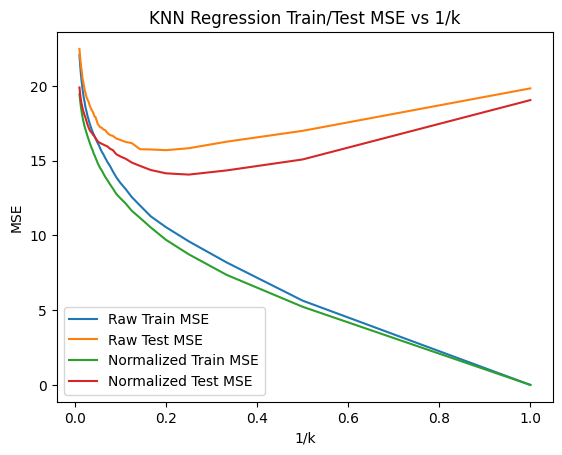

     Features  Best k  Train MSE   Test MSE
0         Raw       5  10.552961  15.704821
1  Normalized       4   8.738516  14.070606


In [15]:
X = df[['AT', 'V', 'AP', 'RH']]
Y = df['PE']

X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.3, random_state=1
)

k_values = list(range(1, 101))

# Raw
raw_train_errors = []
raw_test_errors = []

for k in k_values:
  knn = KNeighborsRegressor(n_neighbors=k)
  knn.fit(X_train, Y_train)

  train_pred = knn.predict(X_train)
  test_pred = knn.predict(X_test)

  train_error = np.mean((Y_train - train_pred) ** 2)
  test_error = np.mean((Y_test - test_pred) ** 2)

  raw_train_errors.append(train_error)
  raw_test_errors.append(test_error)

min_error = min(raw_test_errors)
tied_indices = [i for i, val in enumerate(raw_test_errors) if val == min_error]
tied_k_values = [k_values[i] for i in tied_indices]

raw_k_star = max(tied_k_values)
best_index = k_values.index(raw_k_star)

print(f"Raw features k* = {raw_k_star}")
print(f"Raw features Train MSE = {raw_train_errors[best_index]:.4f}")
print(f"Raw features Test MSE = {raw_test_errors[best_index]:.4f}")


# Normalized
scaler = StandardScaler()

X_train_norm = scaler.fit_transform(X_train)
X_test_norm = scaler.transform(X_test)

norm_train_errors = []
norm_test_errors = []

for k in k_values:
  knn = KNeighborsRegressor(n_neighbors=k)
  knn.fit(X_train_norm, Y_train)

  train_pred = knn.predict(X_train_norm)
  test_pred = knn.predict(X_test_norm)

  train_error = np.mean((Y_train - train_pred) ** 2)
  test_error = np.mean((Y_test - test_pred) ** 2)

  norm_train_errors.append(train_error)
  norm_test_errors.append(test_error)

min_error = min(norm_test_errors)
tied_indices = [i for i, val in enumerate(norm_test_errors) if val == min_error]
tied_k_values = [k_values[i] for i in tied_indices]

norm_k_star = max(tied_k_values)
best_index = k_values.index(norm_k_star)

print(f"Normalized features k* = {norm_k_star}")
print(f"Normalized features Train MSE = {norm_train_errors[best_index]:.4f}")
print(f"Normalized features Test MSE = {norm_test_errors[best_index]:.4f}")

plt.plot(1 / np.array(k_values), raw_train_errors, label='Raw Train MSE')
plt.plot(1 / np.array(k_values), raw_test_errors, label='Raw Test MSE')
plt.plot(1 / np.array(k_values), norm_train_errors, label='Normalized Train MSE')
plt.plot(1 / np.array(k_values), norm_test_errors, label='Normalized Test MSE')

plt.xlabel('1/k')
plt.ylabel('MSE')
plt.title('KNN Regression Train/Test MSE vs 1/k')
plt.legend()
plt.show()

knn_results = pd.DataFrame({
    'Features': ['Raw', 'Normalized'],
    'Best k': [raw_k_star, norm_k_star],
    'Train MSE': [
        raw_train_errors[raw_k_star - 1],
        norm_train_errors[norm_k_star - 1]
    ],
    'Test MSE': [
        raw_test_errors[raw_k_star - 1],
        norm_test_errors[norm_k_star - 1]
    ]
})

print(knn_results)

### (j ) Compare KNN and Linear

The normalized KNN model with k = 4 had the lowest test MSE of 14.0706, compared to 15.7048 for raw KNN and 18.2636 for the regression model. Normalizing the features improved the KNN model because KNN depends on the distance between points. Overall, KNN performed better than the regression model and was able to better capture the relationships in the data.

## 2. ISLR: 2.4.1

 For each of parts (a) through (d), indicate whether we would generally expect the performance of a flexible statistical learning method to be better or worse than an inflexible method. Justify your answer.

### (a) The sample size n is extremely large, and the number of predictors p is small.

When sample n is extremely large and the number of predictors p is small, a flexible model would be better than an inflexible. Because of the large number of observations relative to the number of predictors, there is a lot of data to estimate and fit a more complex model without overfitting. Using a more flexible model can allow for lower bias while keeping variance lower because we have so many data points. An inflexible method (like linear regression) can allow for bias that the data could have resolved.

### (b) The number of predictors p is extremely large, and the number of observations n is small.

When number of predictors is extremely large and number of observations n is small, a flexible model is worse than an inflexible model. Without enough observations, a more flexible model does not have enough data to constrain its degrees of freedom and can overfit the model. The model will fit to noise in the small number of observations and lead to high variance and poor generalization. Having a more inflexible model will be more stable with less observations even if it can introduce more bias.

### (c) The relationship between the predictors and response is highly non-linear.

When the relationship between predictors and response is highly non-linear a flexible model is better than an inflexible one because the unflexible model assumes a specific and simple function form. The inflexible method will also have high bias when the true relationship doesn't follow said shape and no amount of data can fix the wrong form. Using a flexible model can allow it to adapt to the non-linear relationship between the predictors and response, capturing curvature, interactions and any non-linear patterns that the inflexible is unable to. Because of that, the flexible model will generally achieve a lower bias and better fit.

### (d) The variance of the error terms, i.e. $σ^2$ = Var(ε), is extremely high.

When the variance of the error terms is extremely high, a flexible model is worse. This is because error is irreducible and is typically noise. A flexible model would try to fit to the noise (and overfitting to said noise), resulting in higher variance and lower test performance. While an inflexible model is more constrained, allowing the noise to affect the model less and be able to generalize the data more robustly which is better than fitting and "explaining" noise.

## 3. ISLR: 2.4.7

### (a) Compute the Euclidean distance between each observation and the test point, X1 = X2 = X3 = 0.

In [16]:
Q3_df = pd.DataFrame({
    'Obs.': [1, 2, 3, 4, 5, 6],
    'X1': [0, 2, 0, 0, -1, 1],
    'X2': [3, 0, 1, 1, 0, 1],
    'X3': [0, 0, 3, 2, 1, 1],
    'Y': ['Red', 'Red', 'Red', 'Green', 'Green', 'Red']
})

test = np.array([0,0,0])
Q3_df['distance'] = np.sqrt(Q3_df['X1']**2 + Q3_df['X2']**2 + Q3_df['X3']**2)

print(Q3_df)

   Obs.  X1  X2  X3      Y  distance
0     1   0   3   0    Red  3.000000
1     2   2   0   0    Red  2.000000
2     3   0   1   3    Red  3.162278
3     4   0   1   2  Green  2.236068
4     5  -1   0   1  Green  1.414214
5     6   1   1   1    Red  1.732051


### (b) What is our prediction with K = 1? Why?

In [17]:
print(Q3_df.sort_values('distance'))

   Obs.  X1  X2  X3      Y  distance
4     5  -1   0   1  Green  1.414214
5     6   1   1   1    Red  1.732051
1     2   2   0   0    Red  2.000000
3     4   0   1   2  Green  2.236068
0     1   0   3   0    Red  3.000000
2     3   0   1   3    Red  3.162278


Looking at the distances column in the table sorted by distance, we can see that the closest point to [0, 0, 0] is observation 5: [-1, 0, 1] which has the class 'Green'. So, with K=1, our prediction would be 'Green'.

### (c) What is our prediction with K = 3? Why?

Looking at the previous table, we can see that observations 5, 6, and 2 are the 3 closest points to [0, 0, 0] with the classes 'Green', 'Red', 'Red', respectively. Because there are more 'Red' classes than 'Green', our prediction would be 'Red' even though the closest point is 'Green'.

### (d) If the Bayes decision boundary in this problem is highly non-linear, then would we expect the best value for K to be large or small? Why?

If the Bayes decision boundary in this problem is highly non-linear, then we would expect the best value for K to be small. When we have small K, we can create a more flexible and adaptive decision boundary that tracks data more precisely around each point. When we have a large K the prediction averages over the many neighbours, smoothing out the decision boundary. The smoothing of the decision boundary creates more linear like boundaries which would fail to capture the sharper curves and bends of a non-linear boundary.